# Section 3 — cumulative Nash regret vs round $t$

**One figure (2×2):** $n \in \{10,20,50,100\}$. **x-axis:** round $t$ (linear). **y-axis:** $\log_{10}$ (cumulative Nash regret). **Curves:** Nash, Hedge, Our-Algo — mean $\pm$ std over seeds.

Set **`RUN_MODE`** in the code cell: **FAST** (quick check), **STANDARD**, or **HEAVY** (longer $T$ / more seeds).

Saved: D:\Users\Mateo\Personal\_Seminar_RL\Zero-Sum-MatrixGames\Full_information_feedback\Nash_regret_curve_section3\plots\section3_cumulative_nashregret_heavy_T30000.png


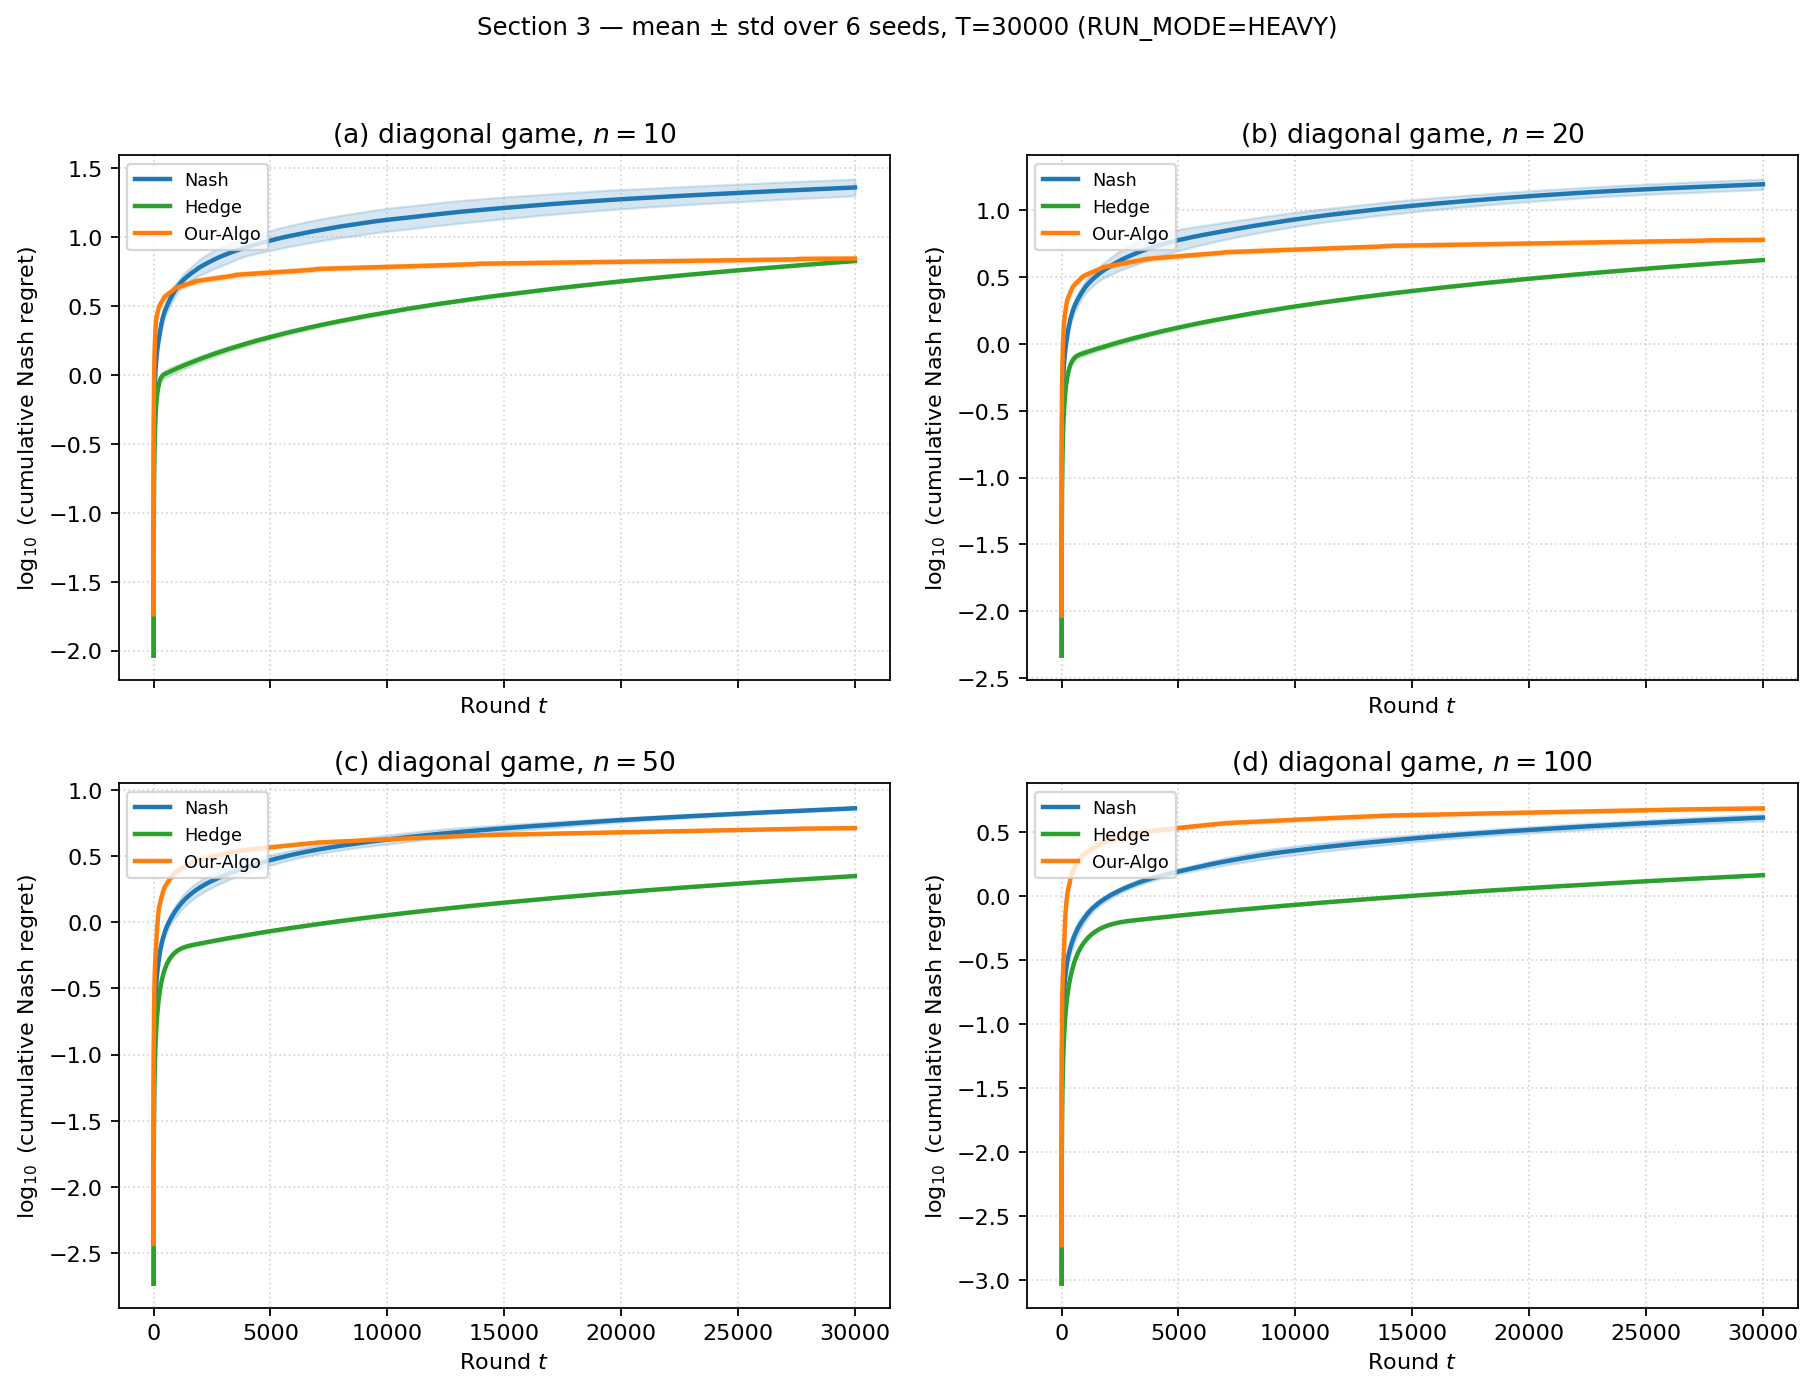

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_here = Path.cwd()
if not (_here / "curves.py").is_file():
    for _cand in (
        _here / "Nash_regret_curve_section3",
        _here / "Full_information_feedback" / "Nash_regret_curve_section3",
    ):
        if (_cand / "curves.py").is_file():
            os.chdir(_cand)
            _here = Path.cwd()
            break
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

from curves import (
    hedge_cumulative_curve,
    mean_std_curves,
    nash_cumulative_curve,
    official_diag_cumulative_curve,
)
from notebook_plot_backend import show_figure_in_notebook

RUN_MODE = "HEAVY"  # "FAST" | "STANDARD" | "HEAVY"

if RUN_MODE == "FAST":
    T, N_RUNS = 4000, 4
elif RUN_MODE == "STANDARD":
    T, N_RUNS = 10000, 16
elif RUN_MODE == "HEAVY":
    T, N_RUNS = 30000, 6
else:
    raise ValueError(RUN_MODE)

BASE_SEED = 7
n_list = (10, 20, 50, 100)
panel_labs = ("(a)", "(b)", "(c)", "(d)")
specs = [
    ("Nash", nash_cumulative_curve, "#1f77b4"),
    ("Hedge", hedge_cumulative_curve, "#2ca02c"),
    ("Our-Algo", official_diag_cumulative_curve, "#ff7f0e"),
]

t_axis = np.arange(1, T + 1, dtype=float)
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.5), sharex=True)
axes_flat = axes.ravel()

for ax, n_actions, lab in zip(axes_flat, n_list, panel_labs):
    for name, fn, color in specs:
        mean_c, std_c = mean_std_curves(fn, T, n_actions, N_RUNS, base_seed=BASE_SEED)
        y = np.log10(mean_c)
        log_std = std_c / np.maximum(mean_c, 1e-12) / np.log(10.0)
        ax.plot(t_axis, y, label=name, color=color, lw=2)
        ax.fill_between(t_axis, y - log_std, y + log_std, alpha=0.18, color=color)
    ax.set_xlabel("Round $t$")
    ax.set_ylabel(r"$\log_{10}$ (cumulative Nash regret)")
    ax.set_title(f"{lab} diagonal game, $n={n_actions}$")
    ax.grid(True, ls=":", alpha=0.5)
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle(
    f"Section 3 — mean ± std over {N_RUNS} seeds, T={T} (RUN_MODE={RUN_MODE})",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()

OUT_DIR = _here / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
fp = OUT_DIR / f"section3_cumulative_nashregret_{RUN_MODE.lower()}_T{T}.png"
plt.savefig(fp, dpi=160, bbox_inches="tight")
print("Saved:", fp.resolve())
show_figure_in_notebook(fig, dpi=160)
plt.close(fig)